#### ResNet
- ResNet : 
- 층이 깊으면 기울기 소실이 발생되는데, ResNet는 기울기 소실 문제를 해결
-  

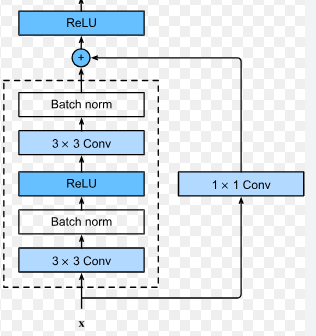

In [ ]:
# [ conv - batchn - Relu - Conv - batchn ]

import torch.nn as nn
import torch

conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
batch1 = nn.BatchNorm2d(32)
relu = nn.ReLU()
conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
batch2 = nn.BatchNorm2d(64)


x = torch.randn(2,3,32,32)
x_ = x #스킵커넥션을 위해서 초기 입력을 저장

x = conv1(x)
x = batch1(x)
x = relu(x)
x = conv2(x)
x = batch2(x)
x.size(), x_.size()   # size를 맞춰줘야..??


(torch.Size([2, 64, 32, 32]), torch.Size([2, 3, 32, 32]))

In [2]:
downsample = nn.Conv2d(3, 64, kernel_size=1)
down_x = downsample(x_)
down_x.size()


torch.Size([2, 64, 32, 32])

In [26]:
import torch
import torch.nn as nnn
class BasicBlock(nn.Module):
    def __init__ (self, in_channel, out_channel, hidden_dim):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channel, hidden_dim, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(hidden_dim, out_channel, kernel_size=3, padding=1)
        self.batch1 = nn.BatchNorm2d(hidden_dim)
        self.batch2 = nn.BatchNorm2d(out_channel)
        self.relu = nn.ReLU()
        self.downsample = nn.Conv2d(in_channel, out_channel, kernel_size=1)

    def forward(self, x):
        x_ = x
        x= self.relu(self.batch1(self.conv1(x)))
        x= self.batch2((self.conv2(x)))

        if self.downsample is not None:
            x_ = self.downsample(x_)

        x += x_
        out = self.relu(x)
        return out

In [27]:
class ResNet (nn.Module):
    def __init__ (self, class_num = 10 ):
        super(ResNet,self).__init__()
        self.b1 = BasicBlock(3, 64, 32) 
        self.b2 = BasicBlock(64, 256, 128) 
        self.b3 = BasicBlock(256, 256, 256)

        self.pool = nn.AvgPool2d(2)

        self.fc1 = nn.Linear(256*4*4, 2048)
        self.fc2 = nn.Linear (2048, 512)
        self.fc3 = nn.Linear (512, class_num)

        self.relu=nn.ReLU()
        self.dropout1 = nn.Dropout(0.2)
        self.dropout2 = nn.Dropout(0.5)

    def forward(self,x):
       x= self.dropout1(self.pool(self.b1(x)))  # 최종 모양 64, 32 32 --> 64, 16, 16
       x= self.dropout1(self.pool(self.b2(x)))  # 256, 8, 8
       x= self.dropout2(self.pool(self.b3(x)))  # 256, 4, 4
       x= torch.flatten(x, start_dim=1)

       x= self.relu(self.fc1(x))
       x= self.relu(self.fc2(x))
       out = self.fc3(x)

       return out


In [28]:
# 데이터는 인간 - 말
# 학습 - 평가



import torch
from torchvision.datasets.cifar import CIFAR10
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize((32,32)),  #이미지 크기 통일
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
])

train_dataset= datasets.ImageFolder(root='./data/horse-or-human/train', transform=transform)
test_dataset= datasets.ImageFolder(root='./data/horse-or-human/test', transform=transform)
train_loader = DataLoader(train_dataset, batch_size=5, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=5, shuffle=False)


#######실행3
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = ResNet(2)
model.to(device)



#######실행4

# 하이퍼 파라미터
from torch.optim import Adam 
lr = 1e-3
optimizer = Adam(model.parameters(), lr=lr)
epochs = 20


from tqdm import tqdm 
# 학습루프
for epoch in range(epochs):
    tqdm_obj= tqdm(train_loader, desc=f'epoch: {epoch+1}/{epochs}')
    for data, label in tqdm_obj:
        optimizer.zero_grad()
        preds = model (data.to(device))
        loss = nn.CrossEntropyLoss()(preds, label.to(device))
        loss.backward()
        optimizer.step()
        
        tqdm_obj.set_postfix(loss=loss.item())

torch.save(model.state_dict(), 'resnet.pth')  #torch에는 모델 저장 기능이 있음 / 가중치만 저장되어있음./ 모델구조는 저장되어 있지 않음. (모델+가중치 저장되는 것도 있음. 용량 많이 차지함)
        


epoch: 20/20: 100%|██████████| 206/206 [00:37<00:00,  5.51it/s, loss=0]       


In [ ]:
# 평가
model.load_state_dict(torch.load('resnet.pth',map_location=device,weights_only=True))
# 예측
# 평가 루프

model.eval()  # 평가 모드로 전환 (dropout, batchnorm 등 비활성화)
total_loss = 0.0
total_correct = 0
total_samples = 0

criterion = nn.CrossEntropyLoss()
with torch.no_grad():  # 그래디언트 계산 비활성화
    for data, label in tqdm(test_loader, desc="Evaluating"):
        data, label = data.to(device), label.to(device)
        preds = model(data)
        loss = criterion(preds, label)
        total_loss += loss.item() * data.size(0)  # 배치 손실 합산
        total_correct += (preds.argmax(dim=1) == label).sum().item()
        total_samples += data.size(0)

avg_loss = total_loss / total_samples
accuracy = total_correct / total_samples

print(f"Test Loss: {avg_loss:.4f}, Test Accuracy: {accuracy:.4f}")

Evaluating: 100%|██████████| 52/52 [00:01<00:00, 26.66it/s]

Test Loss: 1.7000, Test Accuracy: 0.8555


In [31]:
# 평가 ------- train accuracy 확인
model.load_state_dict(torch.load('resnet.pth',map_location=device,weights_only=True))
# 예측
# 평가 루프

model.eval()  # 평가 모드로 전환 (dropout, batchnorm 등 비활성화)
total_loss = 0.0
total_correct = 0
total_samples = 0

criterion = nn.CrossEntropyLoss()
with torch.no_grad():  # 그래디언트 계산 비활성화
    for data, label in tqdm(train_loader, desc="Evaluating"):
        data, label = data.to(device), label.to(device)
        preds = model(data)
        loss = criterion(preds, label)
        total_loss += loss.item() * data.size(0)  # 배치 손실 합산
        total_correct += (preds.argmax(dim=1) == label).sum().item()
        total_samples += data.size(0)

avg_loss = total_loss / total_samples
accuracy = total_correct / total_samples

print(f"Test Loss: {avg_loss:.4f}, Test Accuracy: {accuracy:.4f}")

Evaluating: 100%|██████████| 206/206 [00:10<00:00, 20.37it/s]

Test Loss: 0.0479, Test Accuracy: 0.9873


test accuracy 
Evaluating: 100%|██████████| 52/52 [00:01<00:00, 26.66it/s]Test Loss: 1.7000, Test Accuracy: 0.8555

train accuracy
Evaluating: 100%|██████████| 206/206 [00:10<00:00, 20.37it/s]Test Loss: 0.0479, Test Accuracy: 0.9873

=======> 과적합 dropout 추가.

In [30]:
model.eval()  # 평가 모드로 전환 (dropout, batchnorm 등 비활성화)
total_loss = 0.0
total_correct = 0
total_samples = 0

criterion = nn.CrossEntropyLoss()
with torch.no_grad():  # 그래디언트 계산 비활성화
    for data, label in tqdm(test_loader, desc="Evaluating"):
        data, label = data.to(device), label.to(device)
        preds = model(data)
        loss = criterion(preds, label)
        total_loss += loss.item() * data.size(0)  # 배치 손실 합산
        total_correct += (preds.argmax(dim=1) == label).sum().item()
        total_samples += data.size(0)

avg_loss = total_loss / total_samples
accuracy = total_correct / total_samples

print(f"Test Loss: {avg_loss:.4f}, Test Accuracy: {accuracy:.4f}")

Evaluating: 100%|██████████| 52/52 [00:01<00:00, 26.69it/s]

Test Loss: 1.6387, Test Accuracy: 0.8047


In [25]:
from torchvision.models.resnet import resnet50
resnet50()


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 